In [1]:
import os
import numpy as np
import pandas as pd
import librosa
import joblib
import matplotlib.pyplot as plt
import parselmouth
from parselmouth.praat import call

import xgboost as xgb
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import GroupShuffleSplit
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay

In [2]:
sample_rate = 22050
audio_files_meta = "metadata.csv"
augmented_meta = "metadata_augmented.csv"
in_dir = "audio_files"
out_dir = "audio_files_augmented"
esc50 = "ESC-50/audio"
esc50_meta = "ESC-50/meta/esc50.csv"
times = 4
audio_files_meta = "metadata.csv"

In [3]:
full_df = pd.read_csv("/Users/setkaung/Documents/Code/nlp_project/metadata_augmented.csv")
full_df['original_stem'] = full_df['file_name'].apply(lambda x: x.split('__')[0].replace('.wav', ''))

groups = full_df['original_stem'].values

In [4]:
import os
import time
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from multiprocessing import Pool
from sk.features import extract_features

if __name__ == '__main__':
    
    file_paths = []
    for _, row in full_df.iterrows():
        fname = row["file_name"]
        if not fname.endswith(".wav"):
            fname += ".wav"
            
        if row["augmentation"] == "original":
            path = os.path.join("/Users/setkaung/Documents/Code/nlp_project/audio_files", fname)
        else:
            path = os.path.join("/Users/setkaung/Documents/Code/nlp_project/audio_files_augmented", fname)
            
        file_paths.append(path)

    start = time.time()
    results = []
    completed = 0

    # 2. Run the pool inside the protected block
    with Pool(processes=6) as pool:
        for features in pool.imap(extract_features, file_paths):
            results.append(features)
            completed += 1
            if completed % 240 == 0:
                elapsed = time.time() - start
                print(f"[{completed}/{len(file_paths)}] {elapsed:.1f}s — {elapsed/completed:.2f}s/file")

    X = np.array(results)
    print(f"Done — {time.time()-start:.1f}s total, shape: {X.shape}")

    # Labels
    y_emotion_raw   = np.array(full_df["emotion"].tolist())    

    emotion_encoder = LabelEncoder()

    y_emotion = emotion_encoder.fit_transform(y_emotion_raw)
    y = np.column_stack([y_emotion])

    os.makedirs("models", exist_ok=True)
    np.save("models/X_features_xgboost.npy", X)
    np.save("models/y_labels_xgboost.npy", y)
    
    print("Features and labels saved successfully.")

[240/3360] 21.0s — 0.09s/file
[480/3360] 37.3s — 0.08s/file
[720/3360] 51.4s — 0.07s/file
[960/3360] 55.3s — 0.06s/file
[1200/3360] 59.5s — 0.05s/file
[1440/3360] 63.4s — 0.04s/file
[1680/3360] 67.3s — 0.04s/file
[1920/3360] 70.9s — 0.04s/file
[2160/3360] 75.1s — 0.03s/file
[2400/3360] 79.4s — 0.03s/file
[2640/3360] 83.7s — 0.03s/file
[2880/3360] 88.6s — 0.03s/file
[3120/3360] 93.7s — 0.03s/file
[3360/3360] 98.7s — 0.03s/file
Done — 98.7s total, shape: (3360, 26)
Features and labels saved successfully.


In [5]:
joblib.dump(emotion_encoder, os.path.join("/Users/setkaung/Documents/Code/nlp_project/models", "xgboost_emotion_encoder.pkl"))

['/Users/setkaung/Documents/Code/nlp_project/models/xgboost_emotion_encoder.pkl']

In [15]:
X = np.load("models/X_features_xgboost.npy")
y = np.load("models/y_labels_xgboost.npy")

groups = np.asarray(groups)
if len(groups) != len(X):
    groups = groups[:len(X)]

gss = GroupShuffleSplit(n_splits=1, test_size=0.2, random_state=42)

train_idx, test_idx = next(gss.split(X, y, groups=groups))

X_train, X_test = X[train_idx], X[test_idx]
y_train, y_test = y[train_idx], y[test_idx]


In [16]:
xgb_model = xgb.XGBClassifier()

In [17]:
xgb_model.fit(X_train,y_train)
xgb_model.save_model(os.path.join("/Users/setkaung/Documents/Code/nlp_project/models","xgb_emotion.json"))

In [18]:
y_test_tmp = y_test.reshape(1,-1).flatten()
(y_test_tmp == xgb_model.predict(X_test)).sum() / y_test_tmp.shape[0] * 100

np.float64(43.25925925925926)

In [19]:
emotion_encoder = joblib.load(os.path.join("/Users/setkaung/Documents/Code/nlp_project/models", "xgboost_emotion_encoder.pkl"))

In [22]:
from sk.features import extract_features
def extract_features_chunked(file_path, max_duration=4.0):
    y, _ = librosa.load(file_path, sr=sample_rate, mono=True)

    duration = len(y) / sample_rate

    if duration <= max_duration:
        return extract_features(file_path)
    else:
        chunk_size = int(max_duration * sample_rate)
        chunks = [y[i:i+chunk_size] for i in range(0, len(y)-chunk_size, chunk_size)]

        rms_per_chunk = [librosa.feature.rms(y=c).mean() for c in chunks]
        best_chunk = chunks[np.argmax(rms_per_chunk)]

        import soundfile as sf
        tmp_path = "/tmp/chunk_tmp.wav"
        sf.write(tmp_path, best_chunk, sample_rate)
        return extract_features(tmp_path)

In [23]:
import datetime
import pandas as pd


test_metadata = pd.read_csv('/Users/setkaung/Documents/Code/nlp_project/test_metadata_master.csv')

with open(f"/Users/setkaung/Documents/Code/nlp_project/test_logs/xgb_emotion_{datetime.datetime.now().strftime('%Y-%m-%d_%H-%M-%S')}_other.log", "w") as log:
    out = ""

    for _, row in test_metadata.iterrows():
        file_path = row['file_path']
        audio_id = row['AudioID']
        true_emotion = str(row['Emotion']).lower()
        source = row['source']

        out += f"\n{'=' * 60}\n"
        out += f"File: {file_path} (Source: {source})\n"
        out += f"AudioID: {audio_id}\n"

        try:
            feature = extract_features_chunked(file_path)
            # XGBoost returns 1D array directly: use [0] to get scalar prediction
            prediction = xgb_model.predict(feature.reshape(1, -1))[0]
            predicted_emotion = emotion_encoder.inverse_transform([prediction])[0]

            out += "\nGround Truth:\n"
            out += f"  Emotion: {true_emotion}\n"

            out += "\nPredicted:\n"
            out += f"  Emotion: {predicted_emotion}\n"

            emotion_match = "✓" if predicted_emotion == true_emotion else "✗"
            out += f"\nMatch: Emotion {emotion_match}\n"

        except Exception as e:
            out += f"Error processing file: {type(e).__name__}: {e}\n"

    log.write(out)

print("Testing complete! Results saved to test_logs/xgb_emotion_*.log")
print(f"Total files tested: {len(test_metadata)}")


/Users/setkaung/Documents/Code/nlp_project/sk/features.py:39: PraatWarning: File too small (2-channel 16-bit).
Missing samples were set to zero.
  snd = parselmouth.Sound(file_path)
/Users/setkaung/Documents/Code/nlp_project/sk/features.py:39: PraatWarning: File too small (2-channel 16-bit).
Missing samples were set to zero.
  snd = parselmouth.Sound(file_path)
/Users/setkaung/Documents/Code/nlp_project/sk/features.py:39: PraatWarning: File too small (2-channel 16-bit).
Missing samples were set to zero.
  snd = parselmouth.Sound(file_path)
/Users/setkaung/Documents/Code/nlp_project/sk/features.py:39: PraatWarning: File too small (2-channel 16-bit).
Missing samples were set to zero.
  snd = parselmouth.Sound(file_path)
/Users/setkaung/Documents/Code/nlp_project/sk/features.py:39: PraatWarning: File too small (2-channel 16-bit).
Missing samples were set to zero.
  snd = parselmouth.Sound(file_path)


Testing complete! Results saved to test_logs/xgb_emotion_*.log
Total files tested: 26


/Users/setkaung/Documents/Code/nlp_project/sk/features.py:39: PraatWarning: File too small (2-channel 16-bit).
Missing samples were set to zero.
  snd = parselmouth.Sound(file_path)
/Users/setkaung/Documents/Code/nlp_project/sk/features.py:39: PraatWarning: File too small (2-channel 16-bit).
Missing samples were set to zero.
  snd = parselmouth.Sound(file_path)
/Users/setkaung/Documents/Code/nlp_project/sk/features.py:39: PraatWarning: File too small (2-channel 16-bit).
Missing samples were set to zero.
  snd = parselmouth.Sound(file_path)
/Users/setkaung/Documents/Code/nlp_project/sk/features.py:39: PraatWarning: File too small (2-channel 16-bit).
Missing samples were set to zero.
  snd = parselmouth.Sound(file_path)
/Users/setkaung/Documents/Code/nlp_project/sk/features.py:39: PraatWarning: File too small (2-channel 16-bit).
Missing samples were set to zero.
  snd = parselmouth.Sound(file_path)


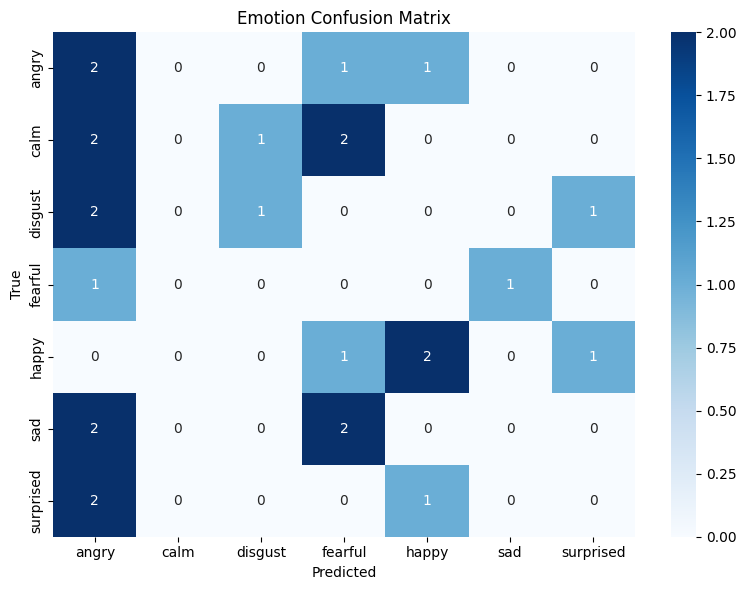

OVERALL ACCURACY
Emotion Accuracy: 19.23%

EMOTION CLASSIFICATION REPORT
              precision    recall  f1-score   support

       angry       0.18      0.50      0.27         4
        calm       0.00      0.00      0.00         5
     disgust       0.50      0.25      0.33         4
     fearful       0.00      0.00      0.00         2
       happy       0.50      0.50      0.50         4
         sad       0.00      0.00      0.00         4
   surprised       0.00      0.00      0.00         3

    accuracy                           0.19        26
   macro avg       0.17      0.18      0.16        26
weighted avg       0.18      0.19      0.17        26



In [24]:
from sklearn.metrics import confusion_matrix, classification_report, accuracy_score
import matplotlib.pyplot as plt
import seaborn as sns

# Re-run predictions to collect all results
test_metadata = pd.read_csv('test_metadata_master.csv')

true_emotions = []
pred_emotions = []

for _, row in test_metadata.iterrows():
    file_path = row['file_path']
    try:
        feature = extract_features_chunked(file_path)
  
        prediction = xgb_model.predict(feature.reshape(1, -1))[0]
        predicted_emotion = emotion_encoder.inverse_transform([prediction])[0]

        true_emotions.append(str(row['Emotion']).lower())
        pred_emotions.append(predicted_emotion)
    except Exception as e:
        print(f"Error processing {file_path}: {type(e).__name__}: {e}")

if len(true_emotions) == 0:
    print("No predictions were collected. Check file paths and model compatibility.")
else:
    fig, ax = plt.subplots(figsize=(8, 6))
    
    cm_emotion = confusion_matrix(true_emotions, pred_emotions, labels=emotion_encoder.classes_)
    sns.heatmap(
        cm_emotion,
        annot=True,
        fmt='d',
        cmap='Blues',
        ax=ax,
        xticklabels=emotion_encoder.classes_,
        yticklabels=emotion_encoder.classes_
    )
    ax.set_title('Emotion Confusion Matrix')
    ax.set_ylabel('True')
    ax.set_xlabel('Predicted')

    plt.tight_layout()
    plt.show()

    emotion_acc = accuracy_score(true_emotions, pred_emotions)
    print("=" * 60)
    print("OVERALL ACCURACY")
    print("=" * 60)
    print(f"Emotion Accuracy: {emotion_acc:.2%}")

    print("\n" + "=" * 60)
    print("EMOTION CLASSIFICATION REPORT")
    print("=" * 60)
    print(classification_report(
        true_emotions,
        pred_emotions,
        labels=emotion_encoder.classes_,
        target_names=emotion_encoder.classes_,
        zero_division=0
    ))